# Figure 1
Map of WRF-Chem-Polar domain including location of measurements used in the study. Also plot maps of anthropogenic and fire aerosol emissions used in the simulations.

In [1]:
import xarray as xr
from glob import glob
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import datetime as dt
import numpy as np
import string

## Read model sea ice field

In [16]:
seaice = xr.open_dataarray("/mnt/data/model_output/ACI_OPT_2/SEAICE.nc").set_index(Time="XTIME")
wrflon, wrflat = seaice.XLONG.isel(Time=0).values, seaice.XLAT.isel(Time=0).values
seaice = seaice.mean("Time")
landmask = xr.open_dataarray("/mnt/data/model_output/ACI_OPT_2/LANDMASK.nc").set_index(Time="XTIME").mean("Time")
land = (landmask).where(~(seaice>0))
ocean = (land!=1)
seaice = seaice.where(ocean)


## Read model emissions

In [11]:
def read_wrfemiss(outputpath, fprefix):
    filenames = glob(outputpath+"/"+fprefix+"*")
    wrfemiss = []
    fmt = f'{outputpath}/{fprefix}_d01_%Y-%m-%d_%H:%M:%S'
    for fname in sorted(filenames):
        date = dt.datetime.strptime(fname,fmt)
        with xr.open_dataset(fname) as ds:
            ds = xr.open_dataset(fname)
            ds = ds.assign_coords({'Times':('Time',[date])}).set_index(Time='Times')
            wrfemiss.append(ds)
    wrfemiss = xr.concat(wrfemiss, dim='Time')
    return wrfemiss


In [13]:
outputpath = "/mnt/data/model_output/real"
wrffirechem = read_wrfemiss(outputpath, "wrffirechemi")
wrfchem = read_wrfemiss(outputpath, "wrfchemi")
wrffirechem, wrfchem

(<xarray.Dataset> Size: 263MB
 Dimensions:          (Time: 168, emissions_zdim_stag: 1, south_north: 99,
                       west_east: 99)
 Coordinates:
   * Time             (Time) datetime64[us] 1kB 2020-04-11 ... 2020-04-17T23:0...
 Dimensions without coordinates: emissions_zdim_stag, south_north, west_east
 Data variables: (12/40)
     ebu_in_co        (Time, emissions_zdim_stag, south_north, west_east) float32 7MB ...
     ebu_in_no        (Time, emissions_zdim_stag, south_north, west_east) float32 7MB ...
     ebu_in_so2       (Time, emissions_zdim_stag, south_north, west_east) float32 7MB ...
     ebu_in_bigalk    (Time, emissions_zdim_stag, south_north, west_east) float32 7MB ...
     ebu_in_bigene    (Time, emissions_zdim_stag, south_north, west_east) float32 7MB ...
     ebu_in_c2h4      (Time, emissions_zdim_stag, south_north, west_east) float32 7MB ...
     ...               ...
     MEAN_FCT_AGSV    (Time, south_north, west_east) float32 7MB 0.0 ... 0.02157
     MEAN_F

In [18]:
wrfchem = wrfchem.assign_coords({
    'longitude': (['south_north','west_east'],wrflon),
    'latitude': (['south_north','west_east'],wrflat),
})
wrffirechem = wrffirechem.assign_coords({
    'longitude': (['south_north','west_east'],wrflon),
    'latitude': (['south_north','west_east'],wrflat),
})


In [19]:
wai = slice(dt.datetime(2020,4,13),dt.datetime(2020,4,16,23,59))
ts_dt = 3600  # s per timestep

bc_fires_sum = (ts_dt*wrffirechem.sel(Time=wai).ebu_in_bc).sum(["Time","emissions_zdim_stag"])  # ug m-2 integrated over whole period
bc_anthro_sum = (ts_dt*wrfchem.sel(Time=wai).E_ECJ).sum(["Time","emissions_zdim_stag"])  # ug m-2 integrated over whole period
oc_fires_sum = (ts_dt*wrffirechem.sel(Time=wai).ebu_in_oc).sum(["Time","emissions_zdim_stag"])  # ug m-2 integrated over whole period
oc_anthro_sum = (ts_dt*wrfchem.sel(Time=wai).E_ORGJ).sum(["Time","emissions_zdim_stag"])  # ug m-2 integrated over whole period
so2_fires_sum = (ts_dt*wrffirechem.sel(Time=wai).ebu_in_so2).sum(["Time","emissions_zdim_stag"])  # ug m-2 integrated over whole period
so2_anthro_sum = (ts_dt*wrfchem.sel(Time=wai).E_SO2).sum(["Time","emissions_zdim_stag"])  # ug m-2 integrated over whole period


## Read MOSAiC and EMEP locations

In [4]:
mosaic = xr.open_dataset("/mnt/data/mosaic/nav/mosaic_coords_2020-04.nc")
mosaic = mosaic.assign_coords({"day": ("time", [T.dt.day for T in mosaic.time])})
emep = xr.open_dataset("/mnt/data/emep/emep_pm25_processed.nc")


## Make figure

In [20]:
matplotlib.rcParams["font.size"] = 18.0
matplotlib.rcParams["lines.linewidth"] = 2.0
matplotlib.rcParams["axes.linewidth"] = 1.2


In [22]:
def rot_pole_from_centre(centre_lat, centre_lon):
    pole_lat = 90 - centre_lat
    pole_lon = centre_lon - 180
    rot_pole = ccrs.RotatedPole(
        pole_latitude=pole_lat,
        pole_longitude=pole_lon
    )
    return rot_pole

def plot_domain_outline(ax, lons_2d, lats_2d, c='k', lw=1, transform=ccrs.Geodetic()):
    for x in [0,-1]:
        ax.plot(
            lons_2d[x,:], lats_2d[x,:],
            c=c, transform=transform, lw=lw,
            zorder=11
        )
        ax.plot(
            lons_2d[:,x], lats_2d[:,x],
            c=c, transform=transform, lw=lw,
            zorder=11
        )
    return


/workspaces/mosaic-wai-wrf-chem-figures/.conda/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


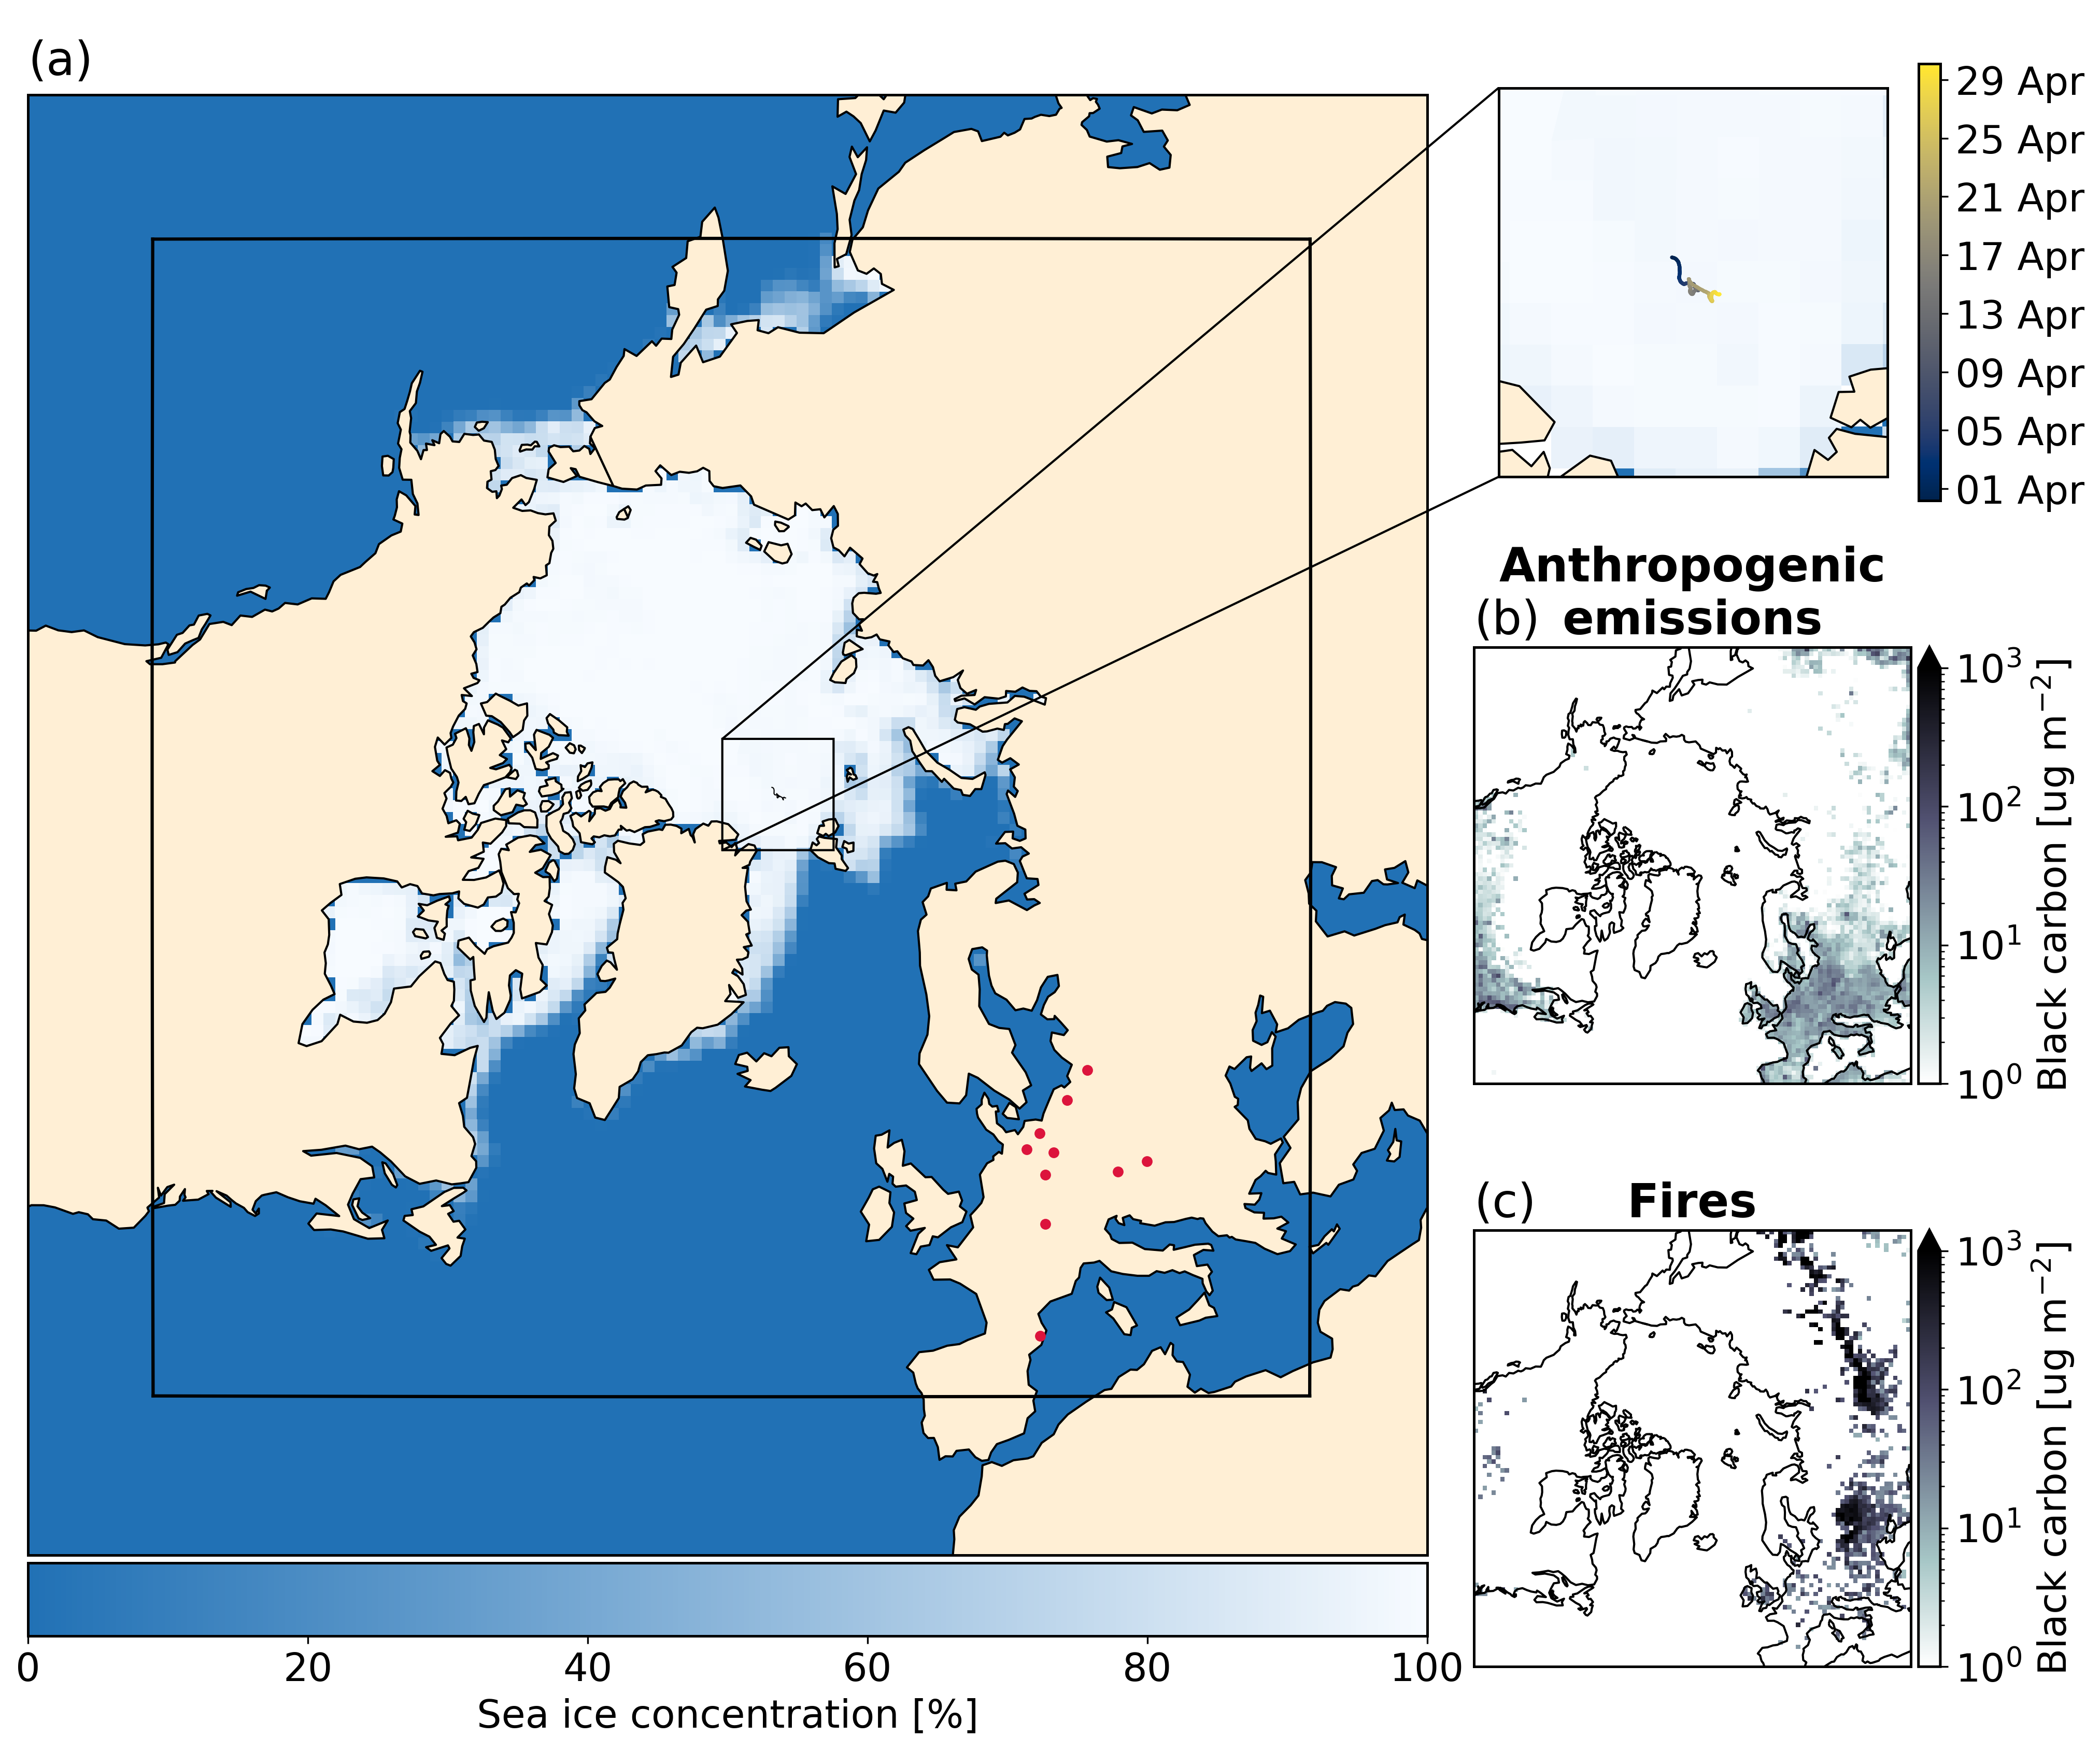

In [24]:
NPS = ccrs.NorthPolarStereo(central_longitude=-25) # central lon=-25 to line up with domain
fig = plt.figure(figsize=(15,15), dpi=300)
# gs = matplotlib.gridspec.GridSpec(nrows=3, ncols=3, figure=fig, width_ratios=[1,2,1])

# set up axes ------------------------------------------
ax = fig.add_subplot([0, 0, 0.6, 1], projection=NPS)
# set extent based on a rotated pole at domain centre
centre_lat, centre_lon = 84, -25
rot_pole = rot_pole_from_centre(centre_lat, centre_lon)
ax.set_extent([-50,50,-45,45], crs=rot_pole)
land = cfeature.NaturalEarthFeature(
    'physical', 'land', '110m',
    edgecolor='k',
)
land_c = 'papayawhip'
ax.add_feature(land, facecolor=land_c, zorder=2)

# -----------------------------------------

# sea ice
cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    "blues_short",
    matplotlib.colormaps["Blues_r"]([0.25,1])
)
ocean_c = matplotlib.colormaps['Blues_r'](0.25)
sic = ax.pcolormesh(
    wrflon,
    wrflat,
    seaice*100,
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=100,
    cmap=cmap,
    zorder=1
)
divider = make_axes_locatable(ax)
cax = divider.append_axes(
    "bottom", size="5%", pad=0.05, axes_class=matplotlib.axes.Axes
)
plt.colorbar(
    sic,
    label='Sea ice concentration [%]',
    shrink=0.8,
    orientation='horizontal',
    pad=0.05,
    cax=cax
)
ax.set_facecolor(ocean_c)

# model domain
plot_domain_outline(ax, wrflon, wrflat, c="k", lw=1.5)

# mosaic
mosaic_c = "k"
ax.plot(
    mosaic.Longitude,
    mosaic.Latitude,
    transform=ccrs.PlateCarree(),
    lw=0.5,
    c=mosaic_c,
    zorder=4
)

# EMEP locations
emep_c = "crimson"
ax.plot(
    emep.lon,
    emep.lat,
    '.', c=emep_c, ms=8,
    transform=ccrs.PlateCarree(),
    zorder=4
)

ax.set_title("(a)", loc="left")

# INSET: axis for zoomed map with MOSAiC track
# use rotated pole to control extent of inset
# *** don't move this code block or figure gets messed up ***
inset_centre_lat, inset_centre_lon = 84.5, 15
inset_pole = rot_pole_from_centre(inset_centre_lat, inset_centre_lon)
ax_ins = ax.inset_axes(
    [0.62, 0.65, 0.2, 0.2],
    transform=fig.transFigure,
    projection=NPS
)
ax_ins.add_feature(land, facecolor=land_c)
ax_ins.set_extent([-3,3,-3,3], crs=inset_pole)
inset_zoom = ax.indicate_inset(inset_ax=ax_ins, edgecolor='k', alpha=1)
for l in inset_zoom.connectors:
    l.set_visible(False)
inset_zoom.connectors[0].set_visible(True)
inset_zoom.connectors[1].set_visible(True)

# sea ice (inset)
ax_ins.pcolormesh(
    wrflon,
    wrflat,
    seaice*100,
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=100,
    cmap=cmap
)

# mosaic (inset)
cmap_mosaic = "cividis"
mosaic_times = [(T - pd.Timestamp(1970,1,1)).total_seconds() for T in mosaic.time.values]
mosaictrack = ax_ins.scatter(
    x=mosaic.Longitude,
    y=mosaic.Latitude,
    c=mosaic_times, s=0.5,
    transform=ccrs.PlateCarree(),
    cmap=cmap_mosaic

)
divider = make_axes_locatable(ax_ins)
cax = divider.append_axes(
    "right", size="5%", pad=0.05, axes_class=matplotlib.axes.Axes
)
cbar = plt.colorbar(mosaictrack, cax=cax, shrink=0.6)
fmt = "%d Apr"
labels = [dt.datetime.strftime(pd.Timestamp(T), fmt) for T in mosaic.time.values]
cbar.set_ticks(labels=labels[20::96], ticks=mosaic_times[20::96])

# anthropogenic bc
ax = fig.add_subplot([0.62,0.4,0.2,0.2], projection=NPS)
ax.coastlines()
C = ax.pcolormesh(
    wrflon,
    wrflat,
    bc_anthro_sum.squeeze(),
    norm=matplotlib.colors.LogNorm(1e0, 1e3),
    cmap="bone_r",
    transform=ccrs.PlateCarree(),
)
ax.set_title("Anthropogenic\nemissions", weight="bold")
divider = make_axes_locatable(ax)
cax = divider.append_axes(
    "right", size="5%", pad=0.05, axes_class=matplotlib.axes.Axes
)
plt.colorbar(C, label="Black carbon [ug m$^{{-2}}$]", shrink=0.6, extend="max", cax=cax)
ax.set_title("(b)", loc="left")
# fires bc
ax = fig.add_subplot([0.62,0.15,0.2,0.2], projection=NPS)
ax.coastlines()
C = ax.pcolormesh(
    wrflon,
    wrflat,
    bc_fires_sum.squeeze(),
    norm=matplotlib.colors.LogNorm(1e0, 1e3),
    cmap="bone_r",
    transform=ccrs.PlateCarree(),
)
ax.set_title("Fires", weight="bold")
divider = make_axes_locatable(ax)
cax = divider.append_axes(
    "right", size="5%", pad=0.05, axes_class=matplotlib.axes.Axes
)
plt.colorbar(C, label="Black carbon [ug m$^{{-2}}$]", shrink=0.6, extend="max", cax=cax)
ax.set_title("(c)", loc="left")


plt.savefig("figures/figure1.png", bbox_inches="tight")